Train images shape: (5734, 18, 288, 288)
Min precipitation: 0.0
Max precipitation: 0.47125235
Mean precipitation: 0.0014155908
Std precipitation: 0.0025928104


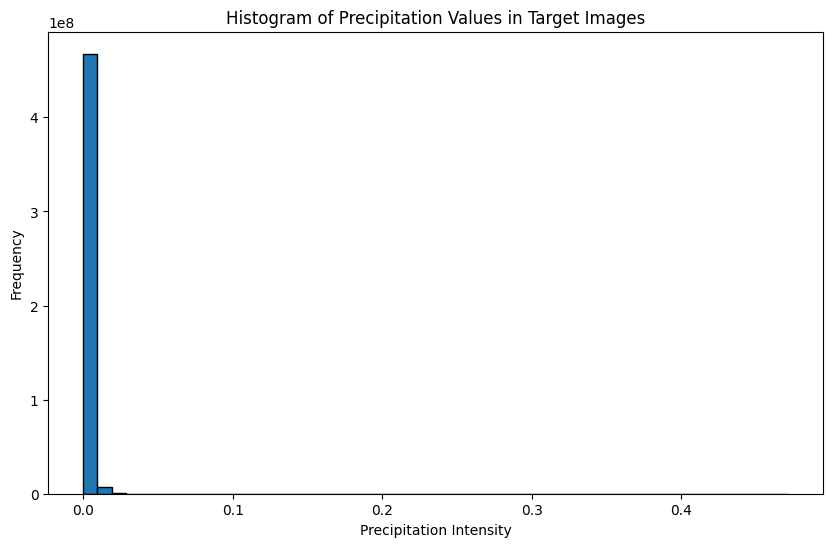


Bin ranges and corresponding percentages:
Range 0.0000 - 0.0094: 98.32%
Range 0.0094 - 0.0189: 1.43%
Range 0.0189 - 0.0283: 0.18%
Range 0.0283 - 0.0377: 0.04%
Range 0.0377 - 0.0471: 0.01%
Range 0.0471 - 0.0566: 0.01%
Range 0.0566 - 0.0660: 0.00%
Range 0.0660 - 0.0754: 0.00%
Range 0.0754 - 0.0848: 0.00%
Range 0.0848 - 0.0943: 0.00%
Range 0.0943 - 0.1037: 0.00%
Range 0.1037 - 0.1131: 0.00%
Range 0.1131 - 0.1225: 0.00%
Range 0.1225 - 0.1320: 0.00%
Range 0.1320 - 0.1414: 0.00%
Range 0.1414 - 0.1508: 0.00%
Range 0.1508 - 0.1602: 0.00%
Range 0.1602 - 0.1697: 0.00%
Range 0.1697 - 0.1791: 0.00%
Range 0.1791 - 0.1885: 0.00%
Range 0.1885 - 0.1979: 0.00%
Range 0.1979 - 0.2074: 0.00%
Range 0.2074 - 0.2168: 0.00%
Range 0.2168 - 0.2262: 0.00%
Range 0.2262 - 0.2356: 0.00%
Range 0.2356 - 0.2451: 0.00%
Range 0.2451 - 0.2545: 0.00%
Range 0.2545 - 0.2639: 0.00%
Range 0.2639 - 0.2733: 0.00%
Range 0.2733 - 0.2828: 0.00%
Range 0.2828 - 0.2922: 0.00%
Range 0.2922 - 0.3016: 0.00%
Range 0.3016 - 0.3110: 0.00%

In [5]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the path to your .h5 file
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]  # shape: (N, T, H, W)
    print("Train images shape:", train_images.shape)

    # Assume the last frame in each sequence is the target.
    target_frame_index = train_images.shape[1] - 1
    
    all_values = []
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        all_values.append(target_img.flatten())
    
    # Concatenate all pixel values from all target images.
    all_values = np.concatenate(all_values)

# Print basic stats
print("Min precipitation:", np.min(all_values))
print("Max precipitation:", np.max(all_values))
print("Mean precipitation:", np.mean(all_values))
print("Std precipitation:", np.std(all_values))

# Plot histogram
num_bins = 50
hist, bin_edges = np.histogram(all_values, bins=num_bins)
plt.figure(figsize=(10, 6))
plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), edgecolor="black", align="edge")
plt.xlabel("Precipitation Intensity")
plt.ylabel("Frequency")
plt.title("Histogram of Precipitation Values in Target Images")
plt.show()

# Print bin ranges and percentages
bin_percentages = 100 * hist / hist.sum()
print("\nBin ranges and corresponding percentages:")
for i in range(len(hist)):
    print(f"Range {bin_edges[i]:.4f} - {bin_edges[i+1]:.4f}: {bin_percentages[i]:.2f}%")


Train images shape: (5734, 18, 288, 288)
Min precipitation: 0.0
Max precipitation: 0.47125235
Mean precipitation: 0.0014155908
Std precipitation: 0.0025928104
Quantile-based boundaries: [0.         0.00020907 0.0008363  0.00229981]
Full bin edges: [0.00000000e+00 0.00000000e+00 2.09073798e-04 8.36295192e-04
 2.29981192e-03 4.71252352e-01]


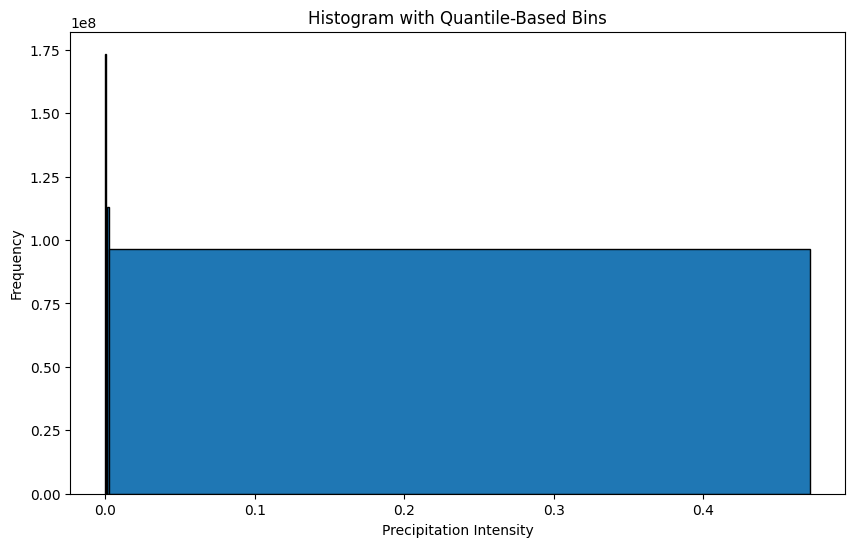


Bin Ranges and Percentages:
Range 0.00000 - 0.00000: 0.00%
Range 0.00000 - 0.00021: 36.47%
Range 0.00021 - 0.00084: 19.42%
Range 0.00084 - 0.00230: 23.80%
Range 0.00230 - 0.47125: 20.32%


In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Replace this with the path to your .h5 file
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]  # shape: (N, T, H, W)
    print("Train images shape:", train_images.shape)

    # Assume the last frame in each sequence is the target.
    target_frame_index = train_images.shape[1] - 1
    
    all_values = []
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        all_values.append(target_img.flatten())
    
    # Concatenate all pixel values from all target images.
    all_values = np.concatenate(all_values)

# Print basic stats
print("Min precipitation:", np.min(all_values))
print("Max precipitation:", np.max(all_values))
print("Mean precipitation:", np.mean(all_values))
print("Std precipitation:", np.std(all_values))

# Let's create 5 buckets total. That means we need 4 boundaries.
# We'll use quantiles to decide the boundary points so that each bucket
# roughly contains the same fraction of pixels.
num_buckets = 5
# For 5 buckets, we need 4 internal boundaries at quantiles [0.2, 0.4, 0.6, 0.8].
# (You could also try [0.25, 0.5, 0.75] for quartiles, etc.)
quantiles = np.linspace(0, 1, num_buckets + 1)  # [0, 0.2, 0.4, 0.6, 0.8, 1.0]
internal_quantiles = quantiles[1:-1]           # [0.2, 0.4, 0.6, 0.8]

boundaries = np.quantile(all_values, internal_quantiles)
print("Quantile-based boundaries:", boundaries)

# For convenience, define full bin edges from min to max:
bin_edges = np.concatenate(([all_values.min()], boundaries, [all_values.max()]))
print("Full bin edges:", bin_edges)

# Compute histogram with these bin edges
hist, bin_edges_used = np.histogram(all_values, bins=bin_edges)
bin_percentages = 100.0 * hist / hist.sum()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.bar(bin_edges_used[:-1], hist, width=np.diff(bin_edges_used), edgecolor="black", align="edge")
plt.xlabel("Precipitation Intensity")
plt.ylabel("Frequency")
plt.title("Histogram with Quantile-Based Bins")
plt.show()

# Print out each bin's range and percentage of pixels
print("\nBin Ranges and Percentages:")
for i in range(len(hist)):
    print(f"Range {bin_edges_used[i]:.5f} - {bin_edges_used[i+1]:.5f}: {bin_percentages[i]:.2f}%")


Train images shape: (5734, 18, 288, 288)

Bin ranges and corresponding percentages:
Range 0.00000 - 0.00333: 87.27%
Range 0.00333 - 0.00667: 8.94%
Range 0.00667 - 0.01000: 2.29%
Range 0.01000 - 0.01333: 0.80%
Range 0.01333 - 0.01667: 0.34%
Range 0.01667 - 0.02000: 0.16%
Range 0.02000 - 0.02333: 0.08%
Range 0.02333 - 0.02667: 0.05%
Range 0.02667 - 0.03000: 0.03%
Range 0.03000 - 0.03333: 0.02%
Range 0.03333 - 0.03667: 0.01%
Range 0.03667 - 0.04000: 0.01%
Range 0.04000 - 0.04333: 0.00%
Range 0.04333 - 0.04667: 0.00%
Range 0.04667 - 0.05000: 0.00%


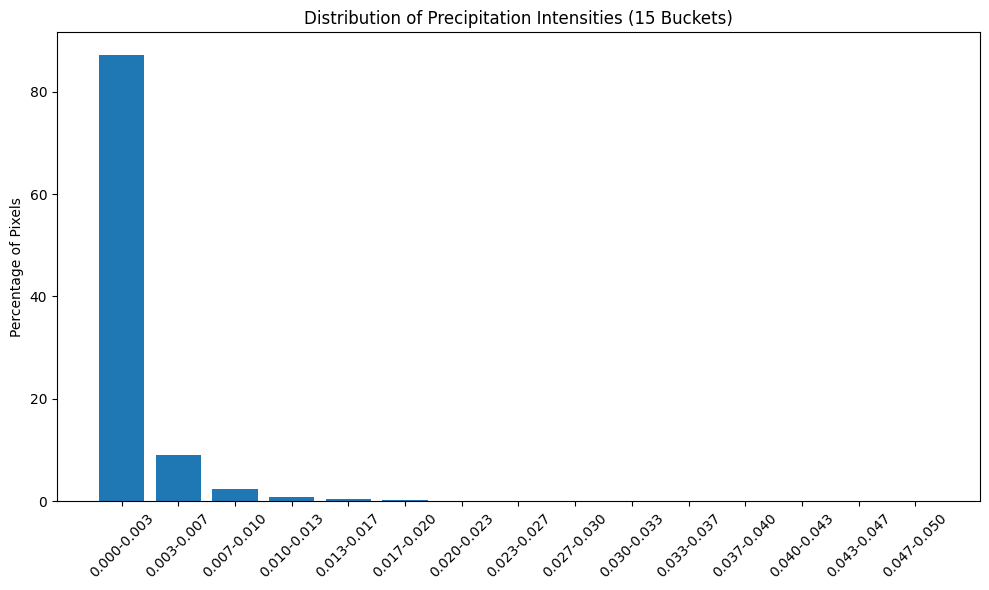

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# File path
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

# Create 15 bins from 0 to max value (you can adjust max)
num_bins = 15
max_precip = 0.05  # Reasonable cap based on your stats (max was ~0.47, but most values are <0.05)
bin_edges = np.linspace(0, max_precip, num_bins + 1)
hist = np.zeros(num_bins)

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    print("Train images shape:", train_images.shape)

    target_frame_index = train_images.shape[1] - 1
    for i in range(train_images.shape[0]):
        # Load only the target image from disk
        target_img = train_images[i, target_frame_index, :, :]
        # Compute histogram for this image
        h, _ = np.histogram(target_img, bins=bin_edges)
        hist += h  # accumulate histogram

# Convert to percentage
total_pixels = hist.sum()
percentages = 100 * hist / total_pixels

# Print bin ranges and percentages
print("\nBin ranges and corresponding percentages:")
for i in range(num_bins):
    print(f"Range {bin_edges[i]:.5f} - {bin_edges[i+1]:.5f}: {percentages[i]:.2f}%")

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(num_bins), percentages, tick_label=[f"{bin_edges[i]:.3f}-{bin_edges[i+1]:.3f}" for i in range(num_bins)])
plt.xticks(rotation=45)
plt.ylabel("Percentage of Pixels")
plt.title("Distribution of Precipitation Intensities (15 Buckets)")
plt.tight_layout()
plt.show()

Train images shape: (5734, 18, 288, 288)

Bin ranges and corresponding percentages (high precision):
Range 0.00000000 - 0.09425047: 99.998735%
Range 0.09425047 - 0.18850094: 0.001164%
Range 0.18850094 - 0.28275141: 0.000088%
Range 0.28275141 - 0.37700188: 0.000010%
Range 0.37700188 - 0.47125235: 0.000003%


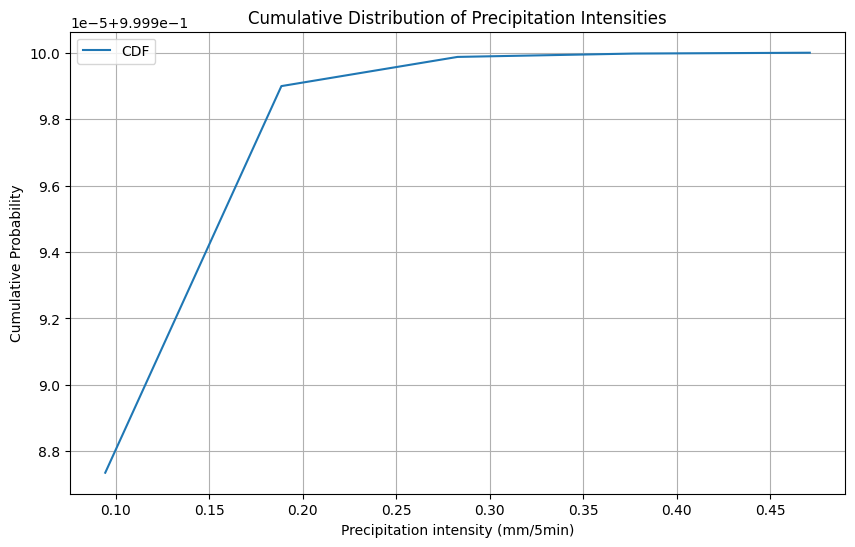

Approximate quantile values for nonzero precipitation:
0.0th percentile: 0.09425
10.0th percentile: 0.09425
20.0th percentile: 0.09425
30.0th percentile: 0.09425
40.0th percentile: 0.09425
50.0th percentile: 0.09425
60.0th percentile: 0.09425
70.0th percentile: 0.09425
80.0th percentile: 0.09425
90.0th percentile: 0.09425
95.0th percentile: 0.09425
99.0th percentile: 0.09425
100.0th percentile: 0.47125


In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# File path
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

# Define histogram parameters
num_bins = 5
max_precip = 0.47125235  # adjust based on your data (most values are below this)
bin_edges = np.linspace(0, max_precip, num_bins + 1)
hist = np.zeros(num_bins, dtype=np.float64)
total_pixels = 0

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    print("Train images shape:", train_images.shape)
    target_frame_index = train_images.shape[1] - 1  # using the last frame as target
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        # Update histogram for this image
        h, _ = np.histogram(target_img, bins=bin_edges)
        hist += h
        total_pixels += target_img.size

# Compute percentage for each bin
percentages = 100 * hist / total_pixels
print("\nBin ranges and corresponding percentages (high precision):")
for i in range(num_bins):
    print(f"Range {bin_edges[i]:.8f} - {bin_edges[i+1]:.8f}: {percentages[i]:.6f}%")

# Compute CDF from the histogram
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

plt.figure(figsize=(10, 6))
plt.plot(bin_edges[1:], cdf, label="CDF")
plt.xlabel("Precipitation intensity (mm/5min)")
plt.ylabel("Cumulative Probability")
plt.title("Cumulative Distribution of Precipitation Intensities")
plt.grid(True)
plt.legend()
plt.show()

# Estimate quantile values (inverse CDF)
# Define desired quantiles (in fraction form)
quantile_fracs = np.array([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1.0])
# np.interp: x = quantile_fracs, xp = cdf, fp = bin_edges[1:]
quantile_values = np.interp(quantile_fracs, cdf, bin_edges[1:])

print("Approximate quantile values for nonzero precipitation:")
for q, val in zip(quantile_fracs, quantile_values):
    print(f"{q*100:.1f}th percentile: {val:.5f}")


In [4]:
# Based on the quantiles I adapted the buckets a bit more to use 5 buckets.

import h5py
import numpy as np

# File path (adjust if necessary)
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

# Set up a high-resolution histogram
num_bins = 1000
max_precip = 0.5  # Using 0.5 as the cap; adjust if needed
bin_edges = np.linspace(0, max_precip, num_bins + 1)
hist = np.zeros(num_bins, dtype=np.float64)
total_pixels = 0

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    print("Train images shape:", train_images.shape)
    target_frame_index = train_images.shape[1] - 1  # using the last frame as target
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        h, _ = np.histogram(target_img, bins=bin_edges)
        hist += h
        total_pixels += target_img.size

# Compute the cumulative distribution function (CDF)
cdf = np.cumsum(hist)
cdf = cdf / cdf[-1]

# Define quantile levels for 5 buckets: 0%, 20%, 40%, 60%, 80%, and 100%
quantile_levels = np.array([0, 0.2, 0.4, 0.6, 0.8, 1.0])
# Interpolate to get the corresponding precipitation values (bin edges)
quantile_values = np.interp(quantile_levels, cdf, bin_edges[1:])

print("Quantile boundaries:")
for q, val in zip(quantile_levels, quantile_values):
    print(f"{q*100:.0f}th percentile: {val:.6f}")

# Define the 5 buckets based on these quantile boundaries and compute their weighted means
buckets = []
bucket_means = []
for i in range(len(quantile_values) - 1):
    lower = quantile_values[i]
    upper = quantile_values[i+1]
    buckets.append((lower, upper))
    # For the weighted mean, consider all bins whose left edge is within [lower, upper)
    mask = (bin_edges[:-1] >= lower) & (bin_edges[:-1] < upper)
    counts = hist[mask]
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    centers = centers[mask]
    if counts.sum() > 0:
        mean_val = np.sum(centers * counts) / counts.sum()
    else:
        mean_val = (lower + upper) / 2
    bucket_means.append(mean_val)

print("\n5 Quantile-Based Buckets and Their Means:")
for i, ((lower, upper), mean_val) in enumerate(zip(buckets, bucket_means)):
    print(f"Bucket {i}: Range {lower:.6f} - {upper:.6f}, Mean: {mean_val:.6f}")


Train images shape: (5734, 18, 288, 288)
Quantile boundaries:
0th percentile: 0.000500
20th percentile: 0.000500
40th percentile: 0.000500
60th percentile: 0.000952
80th percentile: 0.002305
100th percentile: 0.500000

5 Quantile-Based Buckets and Their Means:
Bucket 0: Range 0.000500 - 0.000500, Mean: 0.000500
Bucket 1: Range 0.000500 - 0.000500, Mean: 0.000500
Bucket 2: Range 0.000500 - 0.000952, Mean: 0.000750
Bucket 3: Range 0.000952 - 0.002305, Mean: 0.001573
Bucket 4: Range 0.002305 - 0.500000, Mean: 0.005292


In [6]:
import h5py
import numpy as np

# Define new boundaries: add 0.0 as the lower bound
boundaries = np.array([0.0, 0.00050, 0.00095, 0.00231, 0.01390, 0.08300, 0.50000])
num_buckets = len(boundaries) - 1

hist = np.zeros(num_buckets, dtype=np.float64)
total_pixels = 0

# Path to your HDF5 file
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    print("Train images shape:", train_images.shape)
    target_frame_index = train_images.shape[1] - 1
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        total_pixels += target_img.size
        h, _ = np.histogram(target_img, bins=boundaries)
        hist += h

percentages = 100 * hist / total_pixels

print("\n6 Bucket Distribution (Including Bucket for values < 0.00050):")
for i in range(num_buckets):
    print(f"Bucket {i}: Range {boundaries[i]:.8f} - {boundaries[i+1]:.8f}: {percentages[i]:.4f}%")


Train images shape: (5734, 18, 288, 288)

6 Bucket Distribution (Including Bucket for values < 0.00050):
Bucket 0: Range 0.00000000 - 0.00050000: 49.9178%
Bucket 1: Range 0.00050000 - 0.00095000: 11.1471%
Bucket 2: Range 0.00095000 - 0.00231000: 20.5098%
Bucket 3: Range 0.00231000 - 0.01390000: 17.8059%
Bucket 4: Range 0.01390000 - 0.08300000: 0.6175%
Bucket 5: Range 0.08300000 - 0.50000000: 0.0019%


In [7]:
# New quantile approach where first bucket is the very low precipitation values and then we do quantiles on the other buckets

import h5py
import numpy as np

# File path to your HDF5 file
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

# Define the threshold that separates the very low values from the rest.
very_low_threshold = 0.0005

# We will accumulate values > very_low_threshold
values_above_thresh = []

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    print("Train images shape:", train_images.shape)
    target_frame_index = train_images.shape[1] - 1  # using the last frame as target
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        # Select pixels with values > very_low_threshold
        selected = target_img[target_img > very_low_threshold]
        if selected.size > 0:
            values_above_thresh.append(selected.flatten())
values_above_thresh = np.concatenate(values_above_thresh)
print("Number of pixels above threshold:", len(values_above_thresh))

# Compute quantiles for these values to split into 4 buckets (equal groups)
quantile_levels = [0, 25, 50, 75, 100]  # in percent
quantile_boundaries = np.percentile(values_above_thresh, quantile_levels)
print("Quantile boundaries for pixels > 0.0005:")
for q, val in zip(quantile_levels, quantile_boundaries):
    print(f"{q}th percentile: {val:.8f}")

# Define final bucket boundaries: include bucket 0 for values <= very_low_threshold
# This gives us 5 buckets in total.
final_boundaries = np.concatenate(([0.0], quantile_boundaries))
print("\nFinal bucket boundaries (5 buckets):")
for i in range(len(final_boundaries)-1):
    print(f"Bucket {i}: Range {final_boundaries[i]:.8f} - {final_boundaries[i+1]:.8f}")

# Now compute approximate means for each bucket from the entire dataset.
# We'll use a streaming approach over the target images.
# For simplicity, here we compute means using a histogram approach on the entire dataset.
num_hist_bins = 1000
max_val = 0.5  # use a cap based on your data
hist_edges = np.linspace(0, max_val, num_hist_bins+1)
hist_counts = np.zeros(num_hist_bins, dtype=np.float64)
total_pixels = 0

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    target_frame_index = train_images.shape[1] - 1
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        total_pixels += target_img.size
        h, _ = np.histogram(target_img, bins=hist_edges)
        hist_counts += h

# Compute bin centers
bin_centers = (hist_edges[:-1] + hist_edges[1:]) / 2

# Now, for each final bucket, compute the weighted mean
bucket_means = []
for i in range(len(final_boundaries)-1):
    lower = final_boundaries[i]
    upper = final_boundaries[i+1]
    mask = (bin_centers >= lower) & (bin_centers < upper)
    counts = hist_counts[mask]
    centers = bin_centers[mask]
    if counts.sum() > 0:
        mean_val = np.sum(centers * counts) / counts.sum()
    else:
        mean_val = (lower + upper) / 2
    bucket_means.append(mean_val)

print("\nFinal bucket means:")
for i, mean_val in enumerate(bucket_means):
    print(f"Bucket {i}: Mean = {mean_val:.8f}")


Train images shape: (5734, 18, 288, 288)
Number of pixels above threshold: 238191280
Quantile boundaries for pixels > 0.0005:
0th percentile: 0.00062722
25th percentile: 0.00104537
50th percentile: 0.00167259
75th percentile: 0.00334518
100th percentile: 0.47125235

Final bucket boundaries (5 buckets):
Bucket 0: Range 0.00000000 - 0.00062722
Bucket 1: Range 0.00062722 - 0.00104537
Bucket 2: Range 0.00104537 - 0.00167259
Bucket 3: Range 0.00167259 - 0.00334518
Bucket 4: Range 0.00334518 - 0.47125235

Final bucket means:
Bucket 0: Mean = 0.00025000
Bucket 1: Mean = 0.00075000
Bucket 2: Mean = 0.00125000
Bucket 3: Mean = 0.00237048
Bucket 4: Mean = 0.00666631


In [2]:
import h5py
import numpy as np

# Set parameters for 15 buckets
num_buckets = 15
max_precip = 0.47125235  # adjust as needed
bin_edges = np.linspace(0, max_precip, num_buckets + 1)

# Initialize accumulators for counts and sums per bucket
bucket_counts = np.zeros(num_buckets, dtype=np.float64)
bucket_sums = np.zeros(num_buckets, dtype=np.float64)

h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    target_frame_index = train_images.shape[1] - 1
    num_images = train_images.shape[0]
    for i in range(num_images):
        target_img = train_images[i, target_frame_index, :, :]
        # Flatten the image
        values = target_img.flatten()
        # Find bucket indices for all values at once
        indices = np.digitize(values, bin_edges, right=False) - 1
        # Clip indices in case some values are out of bounds
        indices = np.clip(indices, 0, num_buckets - 1)
        # Accumulate counts and sums using vectorized bincount
        counts = np.bincount(indices, minlength=num_buckets)
        bucket_counts += counts
        bucket_sums += np.bincount(indices, weights=values, minlength=num_buckets)

# Compute the data-driven bucket means
bucket_means = np.divide(bucket_sums, bucket_counts, where=bucket_counts > 0)
for i in range(num_buckets):
    if bucket_counts[i] == 0:
        bucket_means[i] = (bin_edges[i] + bin_edges[i + 1]) / 2

# Compute percentage distribution of pixels per bucket
total_pixels = bucket_counts.sum()
percentages = 100 * bucket_counts / total_pixels

print("15 Bucket Distribution with Data-Driven Means:")
for i in range(num_buckets):
    print(f"Bucket {i}: Range {bin_edges[i]:.8f} - {bin_edges[i+1]:.8f}: {percentages[i]:.4f}%, Mean: {bucket_means[i]:.8f}")

15 Bucket Distribution with Data-Driven Means:
Bucket 0: Range 0.00000000 - 0.03141682: 99.9559%, Mean: 0.00139643
Bucket 1: Range 0.03141682 - 0.06283365: 0.0396%, Mean: 0.03975672
Bucket 2: Range 0.06283365 - 0.09425047: 0.0032%, Mean: 0.07434991
Bucket 3: Range 0.09425047 - 0.12566729: 0.0008%, Mean: 0.10670686
Bucket 4: Range 0.12566729 - 0.15708412: 0.0003%, Mean: 0.13987628
Bucket 5: Range 0.15708412 - 0.18850094: 0.0001%, Mean: 0.17148527
Bucket 6: Range 0.18850094 - 0.21991776: 0.0001%, Mean: 0.20192124
Bucket 7: Range 0.21991776 - 0.25133459: 0.0000%, Mean: 0.23287980
Bucket 8: Range 0.25133459 - 0.28275141: 0.0000%, Mean: 0.26474938
Bucket 9: Range 0.28275141 - 0.31416823: 0.0000%, Mean: 0.29844632
Bucket 10: Range 0.31416823 - 0.34558506: 0.0000%, Mean: 0.32491969
Bucket 11: Range 0.34558506 - 0.37700188: 0.0000%, Mean: 0.35918880
Bucket 12: Range 0.37700188 - 0.40841870: 0.0000%, Mean: 0.38881754
Bucket 13: Range 0.40841870 - 0.43983553: 0.0000%, Mean: 0.42630149
Bucket 14:

In [1]:
# This code is to create 15 buckets with percentage distributions similar to the RainAI paper.

import h5py
import numpy as np

# File path to your HDF5 dataset
h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"

# Desired cumulative percentages for 15 buckets.
# This array should have 16 values (0% and 100% included).
desired_cumperc = np.array([
    0.0,    # Lower bound (always 0%)
    82.0,   # End of bucket 0 => 82% of pixels
    89.0,   # End of bucket 1 => +7%
    93.0,   # End of bucket 2 => +4%
    95.0,   # End of bucket 3 => +2%
    96.5,   # End of bucket 4 => +1.5%
    97.5,   # End of bucket 5 => +1.0%
    98.3,   # End of bucket 6 => +0.8%
    98.9,   # End of bucket 7 => +0.6%
    99.3,   # End of bucket 8 => +0.4%
    99.6,   # End of bucket 9 => +0.3%
    99.8,   # End of bucket 10 => +0.2%
    99.9,   # End of bucket 11 => +0.1%
    99.95,  # End of bucket 12 => +0.05%
    99.98,  # End of bucket 13 => +0.03%
    100.0   # End of bucket 14 => +0.02%
])

num_buckets = len(desired_cumperc) - 1  # should be 15

# 1. Load all target values (assumes the target is the last frame in each sequence)
all_values = []
with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    target_frame_index = train_images.shape[1] - 1
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        all_values.append(target_img.flatten())
all_values = np.concatenate(all_values)
total_pixels = all_values.size
print(f"Total pixels: {total_pixels}")

# 2. Compute the percentile boundaries for these desired cumulative percentages.
# np.percentile expects percentages between 0 and 100.
boundaries = np.percentile(all_values, desired_cumperc)
print("\nDesired Bucket Boundaries (in mm/5min):")
for i in range(len(boundaries)-1):
    print(f"Bucket {i}: [{boundaries[i]:.8f}, {boundaries[i+1]:.8f})")

# 3. For each bucket, compute the mean value (data-driven) and count.
bucket_counts = np.zeros(num_buckets, dtype=np.int64)
bucket_sums = np.zeros(num_buckets, dtype=np.float64)
for i in range(num_buckets):
    lower = boundaries[i]
    upper = boundaries[i+1]
    if i < num_buckets - 1:
        mask = (all_values >= lower) & (all_values < upper)
    else:
        # For the last bucket include values equal to upper
        mask = (all_values >= lower) & (all_values <= upper)
    bucket_counts[i] = np.sum(mask)
    if bucket_counts[i] > 0:
        bucket_sums[i] = all_values[mask].sum()
    else:
        bucket_sums[i] = (lower + upper) / 2.0

bucket_means = bucket_sums / np.maximum(bucket_counts, 1)

# 4. Compute the actual percentages per bucket.
observed_percentages = 100.0 * bucket_counts / total_pixels

# 5. Compute inverse frequency weights: weight_i = 1 / (observed percentage) (or 1/count) normalized.
# Here, we use 1/percentage. (You can choose a different function.)
inv_freq = np.zeros(num_buckets, dtype=np.float64)
for i in range(num_buckets):
    # Avoid division by zero
    if observed_percentages[i] > 0:
        inv_freq[i] = 1.0 / observed_percentages[i]
    else:
        inv_freq[i] = 0.0
# Normalize so that the maximum weight is 1.0 (i.e. rarest bucket gets weight 1.0)
max_weight = inv_freq.max()
bucket_weights = inv_freq / max_weight if max_weight > 0 else inv_freq

# 6. Print the final results.
print("\nFinal 15-Bucket Statistics:")
for i in range(num_buckets):
    print(f"Bucket {i}: Range [{boundaries[i]:.8f}, {boundaries[i+1]:.8f})")
    print(f"    Observed %: {observed_percentages[i]:.4f}%")
    print(f"    Data-Driven Mean: {bucket_means[i]:.8f}")
    print(f"    Inverse-Frequency Weight: {bucket_weights[i]:.4f}")


Total pixels: 475600896

Desired Bucket Boundaries (in mm/5min):
Bucket 0: [0.00000000, 0.00250889)
Bucket 1: [0.00250889, 0.00355425)
Bucket 2: [0.00355425, 0.00480870)
Bucket 3: [0.00480870, 0.00564499)
Bucket 4: [0.00564499, 0.00689944)
Bucket 5: [0.00689944, 0.00794480)
Bucket 6: [0.00794480, 0.00940832)
Bucket 7: [0.00940832, 0.01128998)
Bucket 8: [0.01128998, 0.01338072)
Bucket 9: [0.01338072, 0.01609868)
Bucket 10: [0.01609868, 0.02028016)
Bucket 11: [0.02028016, 0.02487978)
Bucket 12: [0.02487978, 0.03031570)
Bucket 13: [0.03031570, 0.03951495)
Bucket 14: [0.03951495, 0.47125235)

Final 15-Bucket Statistics:
Bucket 0: Range [0.00000000, 0.00250889)
    Observed %: 81.5748%
    Data-Driven Mean: 0.00054374
    Inverse-Frequency Weight: 0.0002
Bucket 1: Range [0.00250889, 0.00355425)
    Observed %: 6.7536%
    Data-Driven Mean: 0.00288018
    Inverse-Frequency Weight: 0.0030
Bucket 2: Range [0.00355425, 0.00480870)
    Observed %: 4.5144%
    Data-Driven Mean: 0.00401641
    Inv

In [2]:
# See how many pixels are very heavy precipitation

import h5py
import numpy as np

h5_file_path = "data/precipitation/train_test_2016-2019_input-length_12_img-ahead_6_rain-threshold_50.h5"
lower_bound = 0.03951495
upper_bound = 0.47125235

total_pixels = 0
bucket_pixels = 0

with h5py.File(h5_file_path, "r") as f:
    train_images = f["train"]["images"]
    target_frame_index = train_images.shape[1] - 1
    for i in range(train_images.shape[0]):
        target_img = train_images[i, target_frame_index, :, :]
        total_pixels += target_img.size
        # Count pixels in the bucket [lower_bound, upper_bound)
        bucket_pixels += np.sum((target_img >= lower_bound) & (target_img < upper_bound))

percentage = 100.0 * bucket_pixels / total_pixels
print(f"Percentage of pixels in bucket [{lower_bound}, {upper_bound}): {percentage:.6f}%")


Percentage of pixels in bucket [0.03951495, 0.47125235): 0.019901%


In [3]:
# Calculate bucket means based on the pixel values of the dataset and not the middle of the boundaries

import torch

def compute_bucket_means(data, boundaries, device=None):
    """
    Computes the bucket means based on the actual pixel values in the dataset.
    
    Args:
        data (torch.Tensor): A tensor of pixel values from your dataset.
        boundaries (torch.Tensor): A tensor containing the bucket boundary values.
        device: Optional device to place the tensors.
        
    Returns:
        torch.Tensor: A tensor of bucket means.
    """
    # Ensure data and boundaries are on the same device
    if device is not None:
        data = data.to(device)
        boundaries = boundaries.to(device)
    else:
        device = data.device

    # Flatten the data in case it's multi-dimensional
    data_flat = data.flatten()

    bucket_means = []
    num_buckets = len(boundaries) + 1  # There are N+1 buckets if there are N boundaries

    for i in range(num_buckets):
        # For the first bucket, include values below the first boundary.
        if i == 0:
            mask = data_flat < boundaries[0]
        # For the last bucket, include values above the last boundary.
        elif i == num_buckets - 1:
            mask = data_flat >= boundaries[-1]
        # For intermediate buckets, include values between boundaries[i-1] and boundaries[i].
        else:
            mask = (data_flat >= boundaries[i - 1]) & (data_flat < boundaries[i])
        
        # Extract the pixel values in this bucket.
        bucket_data = data_flat[mask]
        
        # Compute the mean if there are any pixels; otherwise, default to 0.0.
        if bucket_data.numel() > 0:
            bucket_mean = bucket_data.mean()
        else:
            bucket_mean = torch.tensor(0.0, device=device)
        
        bucket_means.append(bucket_mean)
    
    return torch.tensor(bucket_means, device=device)

# Example usage:
# Your bucket boundaries as provided:
boundaries = torch.tensor([
    0.00333, 0.00667, 0.01000, 0.01333, 0.01667, 0.02000, 0.02333,
    0.02667, 0.03000, 0.03333, 0.03667, 0.04000, 0.04333, 0.04667
])

# Example: Assume 'dataset_pixels' is a torch.Tensor of all pixel values from your dataset.
# For demonstration, let's create a dummy tensor:
dataset_pixels = torch.rand(5734, 64, 64)  # Replace this with your actual dataset tensor

# Compute the data-driven bucket means:
new_bucket_means = compute_bucket_means(dataset_pixels, boundaries)
print(new_bucket_means)


tensor([0.0017, 0.0050, 0.0083, 0.0117, 0.0150, 0.0183, 0.0217, 0.0250, 0.0283,
        0.0317, 0.0350, 0.0383, 0.0417, 0.0450, 0.5234])


In [4]:
def debug_bucket(data, boundaries, bucket_index, device=None):
    """
    Debug function to return the data and statistics of a specific bucket.
    
    Args:
        data (torch.Tensor): Tensor of pixel values.
        boundaries (torch.Tensor): Tensor containing bucket boundaries.
        bucket_index (int): Index of the bucket to inspect.
            For bucket_index == len(boundaries), it corresponds to the last bucket.
        device: Optional device specification.
    
    Returns:
        tuple: (bucket_data, min_value, max_value, mean_value)
    """
    if device is not None:
        data = data.to(device)
        boundaries = boundaries.to(device)
    data_flat = data.flatten()
    
    if bucket_index == 0:
        mask = data_flat < boundaries[0]
    elif bucket_index == len(boundaries):
        mask = data_flat >= boundaries[-1]
    else:
        mask = (data_flat >= boundaries[bucket_index - 1]) & (data_flat < boundaries[bucket_index])
    
    bucket_data = data_flat[mask]
    if bucket_data.numel() > 0:
        min_val = bucket_data.min()
        max_val = bucket_data.max()
        mean_val = bucket_data.mean()
    else:
        min_val = max_val = mean_val = torch.tensor(0.0, device=data.device)
    
    return bucket_data, min_val, max_val, mean_val

# Example usage:
bucket_index = len(boundaries)  # This corresponds to the last bucket.
bucket_data, min_val, max_val, mean_val = debug_bucket(dataset_pixels, boundaries, bucket_index)
print("Last Bucket Statistics:")
print("Min:", min_val.item())
print("Max:", max_val.item())
print("Mean:", mean_val.item())


Last Bucket Statistics:
Min: 0.04667001962661743
Max: 0.9999999403953552
Mean: 0.523389458656311
